# Day 13: Building UIs, Tools & Multimodal AI

Building on Day 12, today we'll explore:
1. Building user interfaces with Gradio
2. Tool calling (function calling)
3. Multimodal AI: images and audio

Let's get started!


## Setup: Import Libraries and Load API Key


In [1]:
# Import everything we need
from openai import OpenAI
from dotenv import load_dotenv
import os
import json
import gradio as gr  # Our UI framework!

# Load API key from .env file
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if api_key and api_key.startswith("sk-"):
    print("API key loaded successfully!")
else:
    print("Error: Check your .env file")


API key loaded successfully!


In [2]:
# Create OpenAI client
client = OpenAI()
MODEL = "gpt-4o-mini"
print(f"Using model: {MODEL}")


Using model: gpt-4o-mini


---
## Part 1: Introduction to Gradio

Gradio lets you build web UIs with just Python. No HTML, CSS, or JavaScript needed!

Let's start with a super simple example.


In [3]:
# A simple function - nothing to do with AI yet
def shout(text):
    """Convert text to uppercase"""
    print(f"shout() was called with: {text}")
    return text.upper()

# Test it
shout("hello world")


shout() was called with: hello world


'HELLO WORLD'

In [4]:
# Now let's create a UI for this function!
# It's just ONE line of code (plus launch)

demo = gr.Interface(
    fn=shout,           # The function to call
    inputs="text",      # Input type
    outputs="text",     # Output type
    title="Shout App"   # Window title
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Part 2: Connecting Gradio to an LLM

Now let's do something more interesting - connect Gradio to GPT!


In [5]:
# A function that calls GPT
def ask_gpt(prompt):
    """Send a prompt to GPT and return the response"""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful assistant. Keep answers brief."},
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

# Test it
ask_gpt("What's 2+2?")


'2 + 2 equals 4.'

In [6]:
# Create a UI for our GPT function
demo = gr.Interface(
    fn=ask_gpt,
    inputs=gr.Textbox(label="Your Question", lines=3),
    outputs=gr.Markdown(label="GPT's Response"),
    title="Ask GPT",
    examples=["Explain Python in one sentence", "What's the capital of France?"]
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


---
## Part 3: Chat Interface

For chat applications, Gradio has a special `ChatInterface` that handles conversation history automatically.


In [7]:
# Chat function - receives message AND history
def chat(message, history):
    """Handle a chat message with conversation history"""
    
    # Build messages list from history
    messages = [
        {"role": "system", "content": "You are a helpful assistant. Keep answers brief."}
    ]
    
    # Add conversation history (history is a list of [user_msg, assistant_msg] pairs)
    for user_msg, assistant_msg in history:
        messages.append({"role": "user", "content": user_msg})
        messages.append({"role": "assistant", "content": assistant_msg})
    
    # Add current message
    messages.append({"role": "user", "content": message})
    
    # Call GPT
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages
    )
    
    return response.choices[0].message.content


In [8]:
# Create a chat interface - super easy!
demo = gr.ChatInterface(
    fn=chat,
    title="Chat with GPT"
)

demo.launch()


c:\Users\HP\.conda\envs\llm-env\Lib\site-packages\gradio\chat_interface.py:339: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


---
## Part 4: Tool Calling (Function Calling)

Now for the exciting part! Tool calling lets LLMs use external functions.

**Key insight:** LLMs don't actually run code - they generate text that ASKS us to run code. We handle the execution!


In [9]:
# Let's create a simple "tool" - a ticket price lookup

# Our "database" of ticket prices
TICKET_PRICES = {
    "london": 799,
    "paris": 899,
    "tokyo": 1420,
    "new york": 550,
    "sydney": 1800
}

def get_ticket_price(city):
    """Look up the ticket price for a city"""
    print(f"Tool called! Looking up price for: {city}")
    
    city_lower = city.lower()
    price = TICKET_PRICES.get(city_lower, None)
    
    if price:
        return f"The ticket price to {city} is ${price}"
    else:
        return f"Sorry, we don't have flights to {city}"

# Test it
print(get_ticket_price("London"))
print(get_ticket_price("Mars"))


Tool called! Looking up price for: London
The ticket price to London is $799
Tool called! Looking up price for: Mars
Sorry, we don't have flights to Mars


In [10]:
# Now we need to describe this tool to the LLM using JSON
# This tells the LLM what the tool does and what parameters it needs

tools = [{
    "type": "function",
    "function": {
        "name": "get_ticket_price",
        "description": "Get the price of a return ticket to a destination city",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "The destination city (e.g., London, Paris, Tokyo)"
                }
            },
            "required": ["city"]
        }
    }
}]

print("Tool definition created!")
print(json.dumps(tools, indent=2))


Tool definition created!
[
  {
    "type": "function",
    "function": {
      "name": "get_ticket_price",
      "description": "Get the price of a return ticket to a destination city",
      "parameters": {
        "type": "object",
        "properties": {
          "city": {
            "type": "string",
            "description": "The destination city (e.g., London, Paris, Tokyo)"
          }
        },
        "required": [
          "city"
        ]
      }
    }
  }
]


In [11]:
# Let's try calling GPT with our tool

messages = [
    {"role": "system", "content": "You are a helpful airline assistant."},
    {"role": "user", "content": "How much is a ticket to London?"}
]

# Call GPT with our tools
response = client.chat.completions.create(
    model=MODEL,
    messages=messages,
    tools=tools  # Pass our tool definitions!
)

# Check what GPT wants to do
print("Finish reason:", response.choices[0].finish_reason)
print("\nMessage:", response.choices[0].message)


Finish reason: tool_calls

Message: ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_DbXfgCq3qkZOI9kIArNwqvPC', function=Function(arguments='{"city":"London"}', name='get_ticket_price'), type='function')])


In [12]:
# Handle the tool call
def handle_tool_call(tool_call):
    """Execute the requested tool and return the result"""
    
    function_name = tool_call.function.name
    arguments = json.loads(tool_call.function.arguments)
    
    print(f"LLM wants to call: {function_name}")
    print(f"With arguments: {arguments}")
    
    # Call the appropriate function
    if function_name == "get_ticket_price":
        result = get_ticket_price(arguments["city"])
    else:
        result = f"Unknown function: {function_name}"
    
    return result

# Get the tool call from the response
tool_call = response.choices[0].message.tool_calls[0]
result = handle_tool_call(tool_call)
print(f"\nTool result: {result}")


LLM wants to call: get_ticket_price
With arguments: {'city': 'London'}
Tool called! Looking up price for: London

Tool result: The ticket price to London is $799


In [13]:
# Now we need to send the result back to GPT for a final answer

# Add the assistant's tool request to the conversation
messages.append(response.choices[0].message)

# Add the tool result
messages.append({
    "role": "tool",
    "tool_call_id": tool_call.id,
    "content": result
})

# Call GPT again with the tool result
final_response = client.chat.completions.create(
    model=MODEL,
    messages=messages,
    tools=tools
)

print("Final answer:")
print(final_response.choices[0].message.content)


Final answer:
The ticket price to London is $799.


---
## Part 5: Complete Chat with Tools

Let's put it all together into a proper chat interface with tool calling:


In [14]:
def chat_with_tools(message, history):
    """Chat function that supports tool calling"""
    
    # Build messages
    messages = [
        {"role": "system", "content": "You are a helpful airline assistant. Use the get_ticket_price tool when asked about prices."}
    ]
    
    # Add history (list of [user_msg, assistant_msg] pairs)
    for user_msg, assistant_msg in history:
        messages.append({"role": "user", "content": user_msg})
        messages.append({"role": "assistant", "content": assistant_msg})
    
    # Add current message
    messages.append({"role": "user", "content": message})
    
    # Call GPT with tools
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools
    )
    
    # Handle tool calls (with a loop for multiple calls)
    while response.choices[0].finish_reason == "tool_calls":
        # Add assistant's message (with tool request)
        messages.append(response.choices[0].message)
        
        # Process each tool call
        for tool_call in response.choices[0].message.tool_calls:
            result = handle_tool_call(tool_call)
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result
            })
        
        # Call GPT again
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools
        )
    
    return response.choices[0].message.content


In [15]:
# Launch our airline assistant!
demo = gr.ChatInterface(
    fn=chat_with_tools,
    title="Airline Assistant",
    examples=[
        "How much is a flight to Paris?",
        "Which is cheaper: London or Tokyo?",
        "I want to go somewhere in Europe"
    ]
)

demo.launch()


c:\Users\HP\.conda\envs\llm-env\Lib\site-packages\gradio\chat_interface.py:339: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


---
## Part 6: Image Generation (Optional)

**⚠️ Note:** Image generation costs ~$0.04 per image. Skip this if you want to avoid charges.


In [16]:
# Some imports for handling images
import base64
from io import BytesIO
from PIL import Image as PILImage  # Rename to avoid conflict with IPython.display.Image

# Function to generate an image with DALL-E (returns PIL Image)
def artist(city):
    """Generate a pop-art vacation image for a city"""
    print(f"Generating image for: {city}")
    
    image_response = client.images.generate(
        model="dall-e-3",
        prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
        size="1024x1024",
        n=1,
        response_format="b64_json"  # Get base64 instead of URL
    )
    
    # Decode base64 to PIL Image
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return PILImage.open(BytesIO(image_data))

print("Image generation function ready!")
print("Run the next cell to generate an image (costs ~$0.04)")


Image generation function ready!
Run the next cell to generate an image (costs ~$0.04)


Generating image for: Paris


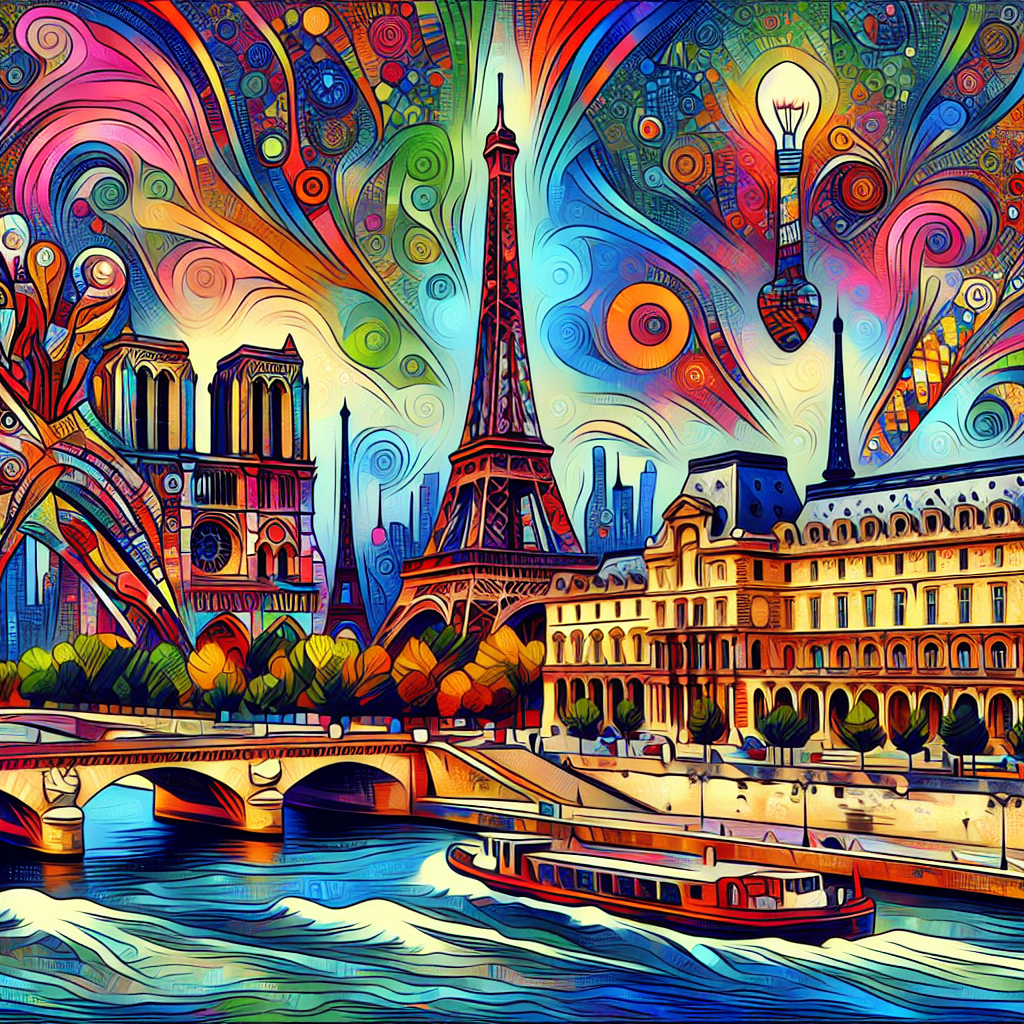

In [17]:
# Test image generation (costs ~$0.04)
# artist() returns a PIL Image directly

image = artist("Paris")
display(image)


---
## Part 7: Text-to-Speech (Optional)

OpenAI can also convert text to natural-sounding speech.


In [18]:
# Function to generate speech
def talker(message):
    """Convert text to speech audio"""
    # Available voices: alloy, echo, fable, nova, onyx, shimmer
    response = client.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="onyx",
        input=message
    )
    return response.content

print("Text-to-speech function ready!")


Text-to-speech function ready!


In [19]:
from IPython.display import Audio

# Test the talker function
audio_content = talker("Hello! Welcome to our airline booking service.")

# Save and play
with open("welcome.mp3", "wb") as f:
    f.write(audio_content)

Audio("welcome.mp3", autoplay=True)


---
## Part 8: Complete Multimodal Assistant

Now let's bring EVERYTHING together - chat with tools, image generation, and audio - all in one interface!


In [20]:
# Tool handler that returns responses AND cities for image generation
def handle_tool_calls_and_return_cities(message):
    """Process all tool calls and return responses + list of cities"""
    responses = []
    cities = []
    
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get("city")
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    
    return responses, cities


In [21]:
# System message for the assistant
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

# The complete multimodal chat function
# For Gradio 5.x: history is list of dicts [{"role": "user", "content": "..."}, ...]
def multimodal_chat(history):
    """
    Chat function that returns:
    - Updated chat history (messages format for Gradio 5.x)
    - Audio of the response  
    - Image of the destination city (if mentioned)
    """
    # Build messages for API (history already has the user message added)
    messages = [{"role": "system", "content": system_message}]
    messages.extend([{"role": h["role"], "content": h["content"]} for h in history])
    
    # Call GPT with tools
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        tools=tools
    )
    
    cities = []
    image = None
    
    # Handle tool calls
    while response.choices[0].finish_reason == "tool_calls":
        msg = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(msg)
        messages.append(msg)
        messages.extend(responses)
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools
        )
    
    # Get final reply
    reply = response.choices[0].message.content
    
    # Add assistant reply to history
    history.append({"role": "assistant", "content": reply})
    
    # Generate audio
    print("Generating audio...")
    voice = talker(reply)
    
    # Generate image if a city was mentioned (costs ~$0.04!)
    if cities:
        print(f"Generating image for: {cities[0]}")
        image = artist(cities[0])
    
    return history, voice, image

print("Multimodal chat function ready!")


Multimodal chat function ready!


In [22]:
# Callback to add user message to chatbot first
def add_user_message(message, history):
    """Add user message to history and clear input"""
    return "", history + [{"role": "user", "content": message}]

# Build the multimodal UI using Gradio Blocks (Gradio 5.x)
with gr.Blocks() as ui:
    gr.Markdown("# ✈️ FlightAI - Multimodal Airline Assistant")
    gr.Markdown("Ask about flight prices and get text, audio, AND images!")
    
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")  # Gradio 5.x messages format
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        msg = gr.Textbox(label="Chat with our AI Assistant:", placeholder="Ask about flights...")
    
    # Event chain: first add message, then process with LLM
    msg.submit(
        add_user_message, 
        inputs=[msg, chatbot], 
        outputs=[msg, chatbot]
    ).then(
        multimodal_chat, 
        inputs=chatbot, 
        outputs=[chatbot, audio_output, image_output]
    )

print("Multimodal UI ready! Run the next cell to launch.")


Multimodal UI ready! Run the next cell to launch.


In [23]:
# Launch the complete multimodal assistant!
# Note: Image generation costs ~$0.04 per city mentioned

ui.launch(inbrowser=True)


* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


Tool called! Looking up price for: Paris
Generating audio...
Generating image for: Paris
Generating image for: Paris


**What's happening in the multimodal assistant:**

1. You type a message (e.g., "How much is a ticket to Paris?")
2. GPT processes it and calls the `get_ticket_price` tool
3. The tool returns the price AND tracks the city name
4. GPT generates a text response
5. **Text-to-speech** converts the response to audio
6. **DALL-E** generates a pop-art image of the destination city
7. All three outputs appear together in the UI!

**⚠️ Cost note:** Each image costs ~$0.04, so asking about multiple cities adds up!


---
## Summary

In this notebook, we learned:

1. **Gradio Basics** - Create UIs with `gr.Interface` and `gr.ChatInterface`
2. **Tool Calling** - Give LLMs the ability to call your functions
3. **Image Generation** - Create images with DALL-E API
4. **Text-to-Speech** - Generate audio from text
5. **Multimodal Interface** - Combine ALL of the above using `gr.Blocks`!

## Key Takeaways

- **Gradio** makes UI creation trivial for Python developers
- **Tool calling** is just structured messaging - no magic!
- **gr.Blocks** gives you full control over layout
- **Multimodal** AI creates rich, engaging experiences

## Your Turn!

Try these exercises:
1. Add a new tool (e.g., `book_flight` that pretends to book)
2. Change the image style (abstract, watercolor, photorealistic)
3. Try different TTS voices (alloy, echo, fable, nova, shimmer)
4. Add more destinations to the ticket price database
